In [2]:
from src.dataset import load_dataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from polynomial_regression import PolynomialRegression
from src.pdf import ProbabilityPDF,build_distribution,make_x_grid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
TRAIN_PATH_X = "../../data/processed/train/train.csv"
RESIDUI_PATH = "../../output/polynomial_regression/residui/residui.csv"
ITERATIONS = 1000
TARGET_COL = "trq_target"
DEGREE = 3

In [4]:
train_data = pd.read_csv(TRAIN_PATH_X)
drop_cols = [TARGET_COL]
X_cols = [c for c in train_data.columns if c not in drop_cols]
X_train = train_data[X_cols].values
y_train = train_data[TARGET_COL].values
model = PolynomialRegression(degree=DEGREE)
model.fit(X_train, y_train)

In [5]:
yhat_train = model.predict(X_train)
residui=pd.DataFrame({
    "residui": y_train-yhat_train,
    "yhat_train": yhat_train,
    "y_train": y_train,
})


In [6]:
mae  = mean_absolute_error(y_train, yhat_train)
mse  = mean_squared_error(y_train, yhat_train)
rmse = np.sqrt(mse)

print(f"MAE  (train): {mae:.4f}")
print(f"MSE  (train): {mse:.4f}")
print(f"RMSE (train): {rmse:.4f}")

r2 = r2_score(y_train, yhat_train)

n = len(y_train)
p = model.poly.n_output_features_

r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R² (train): {r2:.4f}")
print(f"R² adj (train): {r2_adj:.4f}")

MAE  (train): 0.0170
MSE  (train): 0.0008
RMSE (train): 0.0282
R² (train): 1.0000
R² adj (train): 1.0000


In [10]:
residui=load_dataset(RESIDUI_PATH)
distribuistion_target=pd.DataFrame(columns=[TARGET_COL])
target=62.708181
mesured=54.1
trq_margin=-13.727
for i in range(ITERATIONS):
    residuo = residui["residui"].sample().iloc[0]
    distribuistion_target.loc[len(distribuistion_target)]=target+residuo

distribuistion_target['trq_margin'] =((mesured-distribuistion_target['trq_target'])/(distribuistion_target['trq_target']))*100
distribuistion_target.head()

,trq_target,trq_margin
0,62.718065,-13.740961
1,62.695397,-13.709774
2,62.707305,-13.726159
3,62.695166,-13.709456
4,62.697531,-13.712710


In [15]:
x = make_x_grid(-13.727, width=5, n=2000)
pdf_fn = build_distribution(ProbabilityPDF.CAUCHY, -13.727)
y = pdf_fn(x)

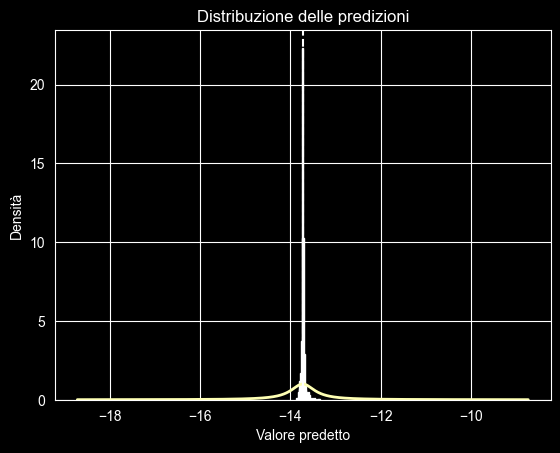

In [16]:
plt.figure()
plt.hist(distribuistion_target["trq_margin"], bins=30, density=True)
plt.plot(x, y, linewidth=2)
plt.axvline(-13.727, linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()